Fanny BADOULES  
Maëlys HANOIRE  
Diane VERBECQ  


# Projet SDP

## Questions d'introduction

Calculez pros(x, y) et cons(x, y).

In [1]:
# Données des contributions (directement d'après le tableau)
delta = {"A": 32, "B": 0, "C": -28, "D": 36, "E": 48, "F": -35, "G": -42}

pros = [k for k, v in delta.items() if v > 0]
cons = [k for k, v in delta.items() if v < 0]
neutral = [k for k, v in delta.items() if v == 0]

print(f"Pros (x, y) : {pros}")
print(f"Cons (x, y) : {cons}")

Pros (x, y) : ['A', 'D', 'E']
Cons (x, y) : ['C', 'F', 'G']


Pouvez-vous énumérer la liste de tous les trade-off de type (1-1) pour la comparaison x ≻ y ?

In [2]:
tradeoffs_11 = []
for p in pros:
    for c in cons:
        if delta[p] + delta[c] > 0:
            tradeoffs_11.append((p, c))

print("\nListe des trade-offs (1-1) valides :")
for t in tradeoffs_11:
    print(f"  - {t} : {delta[t[0]]} + ({delta[t[1]]}) = {delta[t[0]] + delta[t[1]]}")


Liste des trade-offs (1-1) valides :
  - ('A', 'C') : 32 + (-28) = 4
  - ('D', 'C') : 36 + (-28) = 8
  - ('D', 'F') : 36 + (-35) = 1
  - ('E', 'C') : 48 + (-28) = 20
  - ('E', 'F') : 48 + (-35) = 13
  - ('E', 'G') : 48 + (-42) = 6


### Fonction utilitaire pour delta

Le classement repose sur une somme pondérée des notes.  

Pour expliquer la préférence d'un candidat x sur un candidat y, nous calculons la contribution de chaque matière à la différence de score global.  

La contribution d'un critère k est définie par le produit du poids w_k et de l'écart de performance (x_k - y_k).

La fonction compute_delta implémente ce calcul et répartit les critères en trois ensembles :  

pros(x, y) : critères avec une contribution strictement positive (favorisant x).  
cons(x, y) : critères avec une contribution strictement négative (favorisant y).  
neutral(x, y) : critères avec une contribution nulle.  

Cette partition est ensuite utilisée pour construire les trade-offs demandés dans la suite du projet.

In [3]:
def compute_delta(x: dict, y: dict, w: dict, features: list):

    delta = {k: w[k] * (x[k] - y[k]) for k in features}
    pros = [k for k in features if delta[k] > 0]
    cons = [k for k in features if delta[k] < 0]
    neutral = [k for k in features if delta[k] == 0]
    return delta, pros, cons, neutral

## Question 1

Formuler un programme d’optimisation linéaire qui calcule une explication de type (1-1) de la comparaison x ≻ y si elle existe, et retourne un certificat de non-existence dans le cas contraire. Implémentez cette formulation en utilisant un solveur d’optimisation.

L'objectif est de trouver une explication de la comparaison x > y en utilisant des trade-offs de type (1-1). Un trade-off (1-1) est une paire (p, c) où p appartient à pros(x, y) et c appartient à cons(x, y) telle que la somme de leurs contributions est positive ou nulle.

Nous définissons T_1-1 comme l'ensemble des paires admissibles (p, c) telles que delta_p + delta_c >= 0.

Variables de décision :

 z égale à 1 si le trade-off  est inclus dans l'explication.
 u : égale à 1 si le critère favorable  reste inutilisé dans un binôme mais contribue à la justification globale.

Contraintes :  

 Couverture des arguments contre : Chaque critère de  doit être couvert par exactement un trade-off.

 Utilisation des critères pour : Chaque critère de  est utilisé au plus une fois, soit dans un binôme , soit comme argument libre .

 Justification de la préférence stricte : La somme totale des contributions des trade-offs sélectionnés et des critères favorables libres doit être strictement supérieure à zéro () pour valider l'affirmation .

Fonction objectif :  
L'algorithme minimise le nombre de trade-offs utilisés afin de fournir l'explication la plus concise possible.

La fonction solve_11 implémente ce programme linéaire en utilisant le solveur Gurobi. Si le problème est infaisable, cela constitue un certificat de non-existence d'une explication de type (1-1).

In [4]:
from gurobipy import Model, GRB, quicksum

def solve_11(
    x: dict,
    y: dict,
    w: dict,
    features: list,
    model_name: str = "Explanation_1-1",
    silent: bool = True,
    return_iis: bool = False,
):
    delta, pros, cons, neutral = compute_delta(x, y, w, features)

    # Trade-offs admissibles (1-1)
    T_11 = [(p, c) for p in pros for c in cons if delta[p] + delta[c] >= 0]
    n_T_11 = len(T_11)

    m = Model(model_name)
    if silent:
        m.params.OutputFlag = 0

    if n_T_11 == 0 and len(cons) > 0:
        iis = None
        if return_iis:
            try:
                m.computeIIS()
                iis = [con.ConstrName for con in m.getConstrs() if con.IISConstr]
            except:
                iis = ["IIS non disponible (computeIIS a échoué)."]
        return GRB.INFEASIBLE, None, delta, pros, cons, neutral, n_T_11, T_11, m, iis

    z = m.addVars(T_11, vtype=GRB.BINARY, name="z")
    u = m.addVars(pros, vtype=GRB.BINARY, name="u")

    # Chaque con exactement une fois
    for c in cons:
        m.addConstr(
            quicksum(z[p, cc] for (p, cc) in T_11 if cc == c) == 1,
            name=f"cover_{c}"
        )

    # Chaque pro au plus une fois
    for p in pros:
        m.addConstr(
            quicksum(z[pp, c] for (pp, c) in T_11 if pp == p) + u[p] <= 1,
            name=f"usage_{p}"
        )

    # Supériorité stricte
    m.addConstr(
        quicksum(z[p, c] * (delta[p] + delta[c]) for (p, c) in T_11) +
        quicksum(u[p] * delta[p] for p in pros) >= 1e-4,
        name="strict_superiority"
    )

    m.setObjective(quicksum(z[p, c] for (p, c) in T_11), GRB.MINIMIZE)
    m.optimize()

    # Si infaisable et qu'on veut l'IIS
    if m.Status == GRB.INFEASIBLE and return_iis:
        iis = None
        try:
            m.computeIIS()
            iis = [con.ConstrName for con in m.getConstrs() if con.IISConstr]
        except:
            iis = ["IIS non disponible (computeIIS a échoué)."]
        return m.Status, None, delta, pros, cons, neutral, n_T_11, T_11, m, iis

    if m.Status == GRB.OPTIMAL:
        E = [(p, c) for (p, c) in T_11 if z[p, c].X > 0.5]
        return m.Status, E, delta, pros, cons, neutral, n_T_11, T_11, m, None

    return m.Status, None, delta, pros, cons, neutral, n_T_11, T_11, m, None


In [5]:
from gurobipy import GRB

def print_results(
    res,
    show_T: bool = True,
    show_delta: bool = True,
    show_iis: bool = True,
    explanation_type: str = None,
    pair_label: str = None,
):
    """
    res peut être au format :
      - ancien : (status, E, delta, pros, cons, neutral, nT, T, model)
      - nouveau : (status, E, delta, pros, cons, neutral, nT, T, model, iis)

    iis : None ou liste de noms de contraintes (IIS)
    """

    if len(res) == 9:
        status, E, delta, pros, cons, neutral, nT, T, _ = res
        iis = None
    elif len(res) == 10:
        status, E, delta, pros, cons, neutral, nT, T, _, iis = res
    else:
        raise ValueError(f"Format res inattendu (len={len(res)}). Attendu 9 ou 10 éléments.")

    print("status =", status, "(OPTIMAL)" if status == GRB.OPTIMAL else "")
    if delta is not None:
        print("Δ (somme) =", sum(delta.values()))

    if show_delta:
        print("Δ =", delta)

    print("pros =", pros)
    print("cons =", cons)
    print("neutral =", neutral)

    print("\nNombre de trade-offs admissibles |T| =", nT)
    if show_T:
        print("T =", T)

    print("\nE =", E)
    if status == GRB.OPTIMAL and E is not None:
        print("Longueur l =", len(E))

    # Affichage IIS si demandé
    if show_iis and status == GRB.INFEASIBLE:
        if iis is None:
            print("\nIIS : non calculé (mettre return_iis=True dans le solveur).")
        else:
            print("\nIIS (contraintes minimales en conflit) :")
            for name in iis:
                print(" -", name)

    if explanation_type is not None and pair_label is not None:
        if status == GRB.INFEASIBLE:
            print(f"\nConclusion : aucune explication de type ({explanation_type}) n'existe pour la comparaison {pair_label} (modèle infaisable).")
        elif status == GRB.OPTIMAL:
            print(f"\nConclusion : une explication de type ({explanation_type}) existe pour la comparaison {pair_label}.")
        else:
            print(f"\nConclusion : statut inattendu ({status}) pour la comparaison {pair_label}.")


Données de l'exemple x (Xavier) vs y (Yvonne)

In [6]:
courses = ["A","B","C","D","E","F","G"]

x = {"A":85, "B":81, "C":71, "D":69, "E":75, "F":81, "G":88}
y = {"A":81, "B":81, "C":75, "D":63, "E":67, "F":88, "G":95}

w = {"A":8, "B":7, "C":7, "D":6, "E":6, "F":5, "G":6}

In [7]:
res = solve_11(x, y, w, courses,return_iis=True)
print_results(res, show_T=True, show_delta=True,explanation_type="1-1", pair_label="x > y")

Set parameter Username
Set parameter LicenseID to value 2755078
Academic license - for non-commercial use only - expires 2026-12-15
status = 2 (OPTIMAL)
Δ (somme) = 11
Δ = {'A': 32, 'B': 0, 'C': -28, 'D': 36, 'E': 48, 'F': -35, 'G': -42}
pros = ['A', 'D', 'E']
cons = ['C', 'F', 'G']
neutral = ['B']

Nombre de trade-offs admissibles |T| = 6
T = [('A', 'C'), ('D', 'C'), ('D', 'F'), ('E', 'C'), ('E', 'F'), ('E', 'G')]

E = [('A', 'C'), ('D', 'F'), ('E', 'G')]
Longueur l = 3

Conclusion : une explication de type (1-1) existe pour la comparaison x > y.


On considère maintenant plus de candidats dont les notes sont reportées dans la table ci-dessous, et conduisent le classement suivant : x ≻ y ≻ z ≻ t ≻ u ≻ v ≻ w ≻ w′.

In [8]:
scores = {
    "x": {"A":85, "B":81, "C":71, "D":69, "E":75, "F":81, "G":88},
    "y": {"A":81, "B":81, "C":75, "D":63, "E":67, "F":88, "G":95},
    "z": {"A":74, "B":89, "C":74, "D":81, "E":68, "F":84, "G":79},
    "t": {"A":74, "B":71, "C":84, "D":91, "E":77, "F":76, "G":73},
    "u": {"A":72, "B":75, "C":66, "D":85, "E":88, "F":66, "G":93},
    "v": {"A":71, "B":73, "C":63, "D":92, "E":76, "F":79, "G":93},
    "w": {"A":79, "B":69, "C":78, "D":76, "E":67, "F":84, "G":79},
    "w'":{"A":57, "B":76, "C":81, "D":76, "E":82, "F":86, "G":77},
}

#### Montrer par un argument simple qu’il n’existe pas d’explication de type (1-1) de la comparaison w > w′.

Pour prouver l'inexistence d'une explication (1-1) entre w et w', l'argument le plus simple est de comparer le nombre de critères favorables (pros) et défavorables (cons). Une explication (1-1) nécessite par définition de pouvoir couvrir chaque "con" par un "pro" distinct.

In [9]:
delta_ww, pros_ww, cons_ww, neutral_ww = compute_delta(scores["w"], scores["w'"], w, courses)

print(f"Pros: {pros_ww} (Nombre: {len(pros_ww)})")
print(f"Cons: {cons_ww} (Nombre: {len(cons_ww)})")

Pros: ['A', 'G'] (Nombre: 2)
Cons: ['B', 'C', 'E', 'F'] (Nombre: 4)


Pour qu'une explication de type (1-1) existe, il est nécessaire que chaque critère défavorable soit associé à un critère favorable distinct. Cela implique mathématiquement que le nombre de critères dans pros(w, w') doit être supérieur ou égal au nombre de critères dans cons(w, w').


En calculant les contributions pour w et w', nous obtenons :  
pros(w, w') : {A, G} (soit 2 critères).  
cons(w, w') : {B, C, E, F} (soit 4 critères).  
neutral(w, w') : {D}.  

Argument simple :  
Le nombre d'arguments favorables (2) est strictement inférieur au nombre d'arguments défavorables (4).  
Il est donc impossible de construire des paires disjointes couvrant l'intégralité de l'ensemble cons(w, w').  

Par conséquent, aucune explication de type (1-1) n'existe pour cette comparaison.

## Question 2
Formuler un programme d’optimisation linéaire qui calcule une explication de type (1-m) de la comparaison x > y si elle existe, et retourne un certificat de non-existence dans le cas contraire. Implémentez cette formulation en utilisant un solveur d’optimisation.

L'explication de type (1-m) étend le langage précédent en permettant d'associer un unique critère favorable P à un sous-ensemble de critères défavorables {C_1,..., C_m}.

Un trade-off (1-m) est admissible si la contribution du critère "pro" compense la somme des contributions des critères "cons" associés.  

Variables de décision :
z : indique si le critère p qui appartient à pros(x,y) est associé au sous-ensemble S inclu dans cons(x,y).  
u : indique si un critère favorable p n'est pas utilisé dans un trade-off mais participe à la justification globale.

Contraintes :  

Partition des critères contre : Chaque critère défavorable c appartient à cons(x,y) doit appartenir à exactement un sous-ensemble S sélectionné.  
Utilisation unique des critères pour : Chaque critère favorable p appartient à pros(x,y) est utilisé au plus une fois, soit pour compenser un groupe de critères "cons", soit comme argument seul (u).

Justification de la préférence stricte : 

La somme pondérée totale de l'explication (paires et critères libres) doit être strictement positive pour garantir x > y.

Fonction objectif :

Le programme minimise le nombre total de trade-offs pour maximiser la clarté de l'explication.

La fonction solve_1m génère l'ensemble des sous-ensembles de critères défavorables et résout le problème de couverture exacte via Gurobi.

In [10]:
from itertools import combinations
from gurobipy import Model, GRB, quicksum

def solve_1m(
    x: dict,
    y: dict,
    w: dict,
    features: list,
    model_name: str = "Explanation_1-m",
    silent: bool = True,
    return_iis: bool = False,
):
    delta, pros, cons, neutral = compute_delta(x, y, w, features)

    def all_nonempty_subsets(lst):
        out = []
        for r in range(1, len(lst) + 1):
            out.extend(combinations(lst, r))
        return out

    # Trade-offs admissibles (1-m)
    T_1m = []
    for p in pros:
        for S in all_nonempty_subsets(cons):
            if delta[p] + sum(delta[c] for c in S) >= 0:
                T_1m.append(("1m", p, S))

    n_T_1m = len(T_1m)

    m = Model(model_name)
    if silent:
        m.params.OutputFlag = 0

    # Cas sans trade-offs possibles
    if n_T_1m == 0 and len(cons) > 0:
        iis = None
        if return_iis:
            try:
                m.computeIIS()
                iis = [con.ConstrName for con in m.getConstrs() if con.IISConstr]
            except:
                iis = ["IIS non disponible (computeIIS a échoué)."]
        return GRB.INFEASIBLE, None, delta, pros, cons, neutral, n_T_1m, T_1m, m, iis

    z = m.addVars(T_1m, vtype=GRB.BINARY, name="z")
    u = m.addVars(pros, vtype=GRB.BINARY, name="u")

    # Chaque con exactement une fois
    for c in cons:
        m.addConstr(
            quicksum(z[t] for t in T_1m if c in t[2]) == 1,
            name=f"cover_{c}"
        )

    # Chaque pro au plus une fois (utilisé ou libre)
    for p in pros:
        m.addConstr(
            quicksum(z[t] for t in T_1m if t[1] == p) + u[p] <= 1,
            name=f"usage_{p}"
        )

    # Condition de supériorité stricte de x sur y
    m.addConstr(
        quicksum(z[t] * (delta[t[1]] + sum(delta[c] for c in t[2])) for t in T_1m) +
        quicksum(u[p] * delta[p] for p in pros) >= 1e-4,
        name="strict_superiority"
    )

    # Objectif : minimiser le nombre de trade-offs
    m.setObjective(quicksum(z[t] for t in T_1m), GRB.MINIMIZE)
    m.optimize()

    # Si infaisable et qu'on veut l'IIS
    if m.Status == GRB.INFEASIBLE and return_iis:
        iis = None
        try:
            m.computeIIS()
            iis = [con.ConstrName for con in m.getConstrs() if con.IISConstr]
        except:
            iis = ["IIS non disponible (computeIIS a échoué)."]
        return m.Status, None, delta, pros, cons, neutral, n_T_1m, T_1m, m, iis

    if m.Status == GRB.OPTIMAL:
        E = [t for t in T_1m if z[t].X > 0.5]
        return m.Status, E, delta, pros, cons, neutral, n_T_1m, T_1m, m, None

    return m.Status, None, delta, pros, cons, neutral, n_T_1m, T_1m, m, None


Montrer qu’il n’existe pas d’explication de type (1-m) pour la comparaison u ≻ v.

In [11]:
from gurobipy import GRB

u = scores["u"]
v = scores["v"]

res = solve_1m(u, v, w, courses, model_name="Explanation_1-m_u_gt_v", silent=True,return_iis=True)

print_results(res, show_T=True, show_delta=True)

status, E, delta, pros, cons, neutral, nT, T, _,iss = res

if status == GRB.INFEASIBLE:
    print("Conclusion : aucune explication de type (1-m) n'existe pour la comparaison u ≻ v (modèle infaisable).")
elif status == GRB.OPTIMAL:
    print("Une explication (1-m) a été trouvée, donc ce n'est pas infaisable.")
    print("E =", E)
else:
    print("nStatut inattendu :", status)


status = 3 
Δ (somme) = 8
Δ = {'A': 8, 'B': 14, 'C': 21, 'D': -42, 'E': 72, 'F': -65, 'G': 0}
pros = ['A', 'B', 'C', 'E']
cons = ['D', 'F']
neutral = ['G']

Nombre de trade-offs admissibles |T| = 2
T = [('1m', 'E', ('D',)), ('1m', 'E', ('F',))]

E = None

IIS (contraintes minimales en conflit) :
 - cover_D
 - cover_F
 - usage_E
Conclusion : aucune explication de type (1-m) n'existe pour la comparaison u ≻ v (modèle infaisable).


Trouver une explication de type (m-1) pour la comparaison y ≻ z.

In [12]:
delta, pros, cons, neutral = compute_delta(scores["y"], scores["z"], w, courses)

print(f"Pros (en faveur de y) : {pros}")
print(f"Cons (en faveur de z) : {cons}")
for k, v in delta.items():
    if v != 0: print(f"  {k}: {v}")

explication_m1 = [
    (["A"], "B"),
    (["C"], "E"),
    (["G", "F"], "D")
]

valid_global = True

for p_list, c in explication_m1:
    sum_pros = sum(delta[p] for p in p_list)
    val_con = delta[c]
    balance = sum_pros + val_con
    
    status = "OK" if balance >= 0 else "ECHEC"
    if balance < 0: valid_global = False
    

if valid_global:
    print("Explication valide : Tous les désavantages sont couverts.")
else:
    print("Explication invalide.")

Pros (en faveur de y) : ['A', 'C', 'F', 'G']
Cons (en faveur de z) : ['B', 'D', 'E']
  A: 56
  B: -56
  C: 7
  D: -108
  E: -6
  F: 20
  G: 96
Explication valide : Tous les désavantages sont couverts.


Explication de type (m-1) pour la comparaison :

Pour justifier la préférence de y sur z, nous devons expliquer pourquoi les faiblesses de y (critères Cons) sont acceptables au regard de ses points forts (critères Pros).

L'analyse des contributions montre trois désavantages à couvrir :

Biologie (B) : perte importante de -56.
Diagnotic (D): perte critique de -108.
Épidémiologie (E) : perte mineure de -6.

Une explication de type (m-1) permet de regrouper plusieurs points forts pour compenser une seule faiblesse. Voici l'explication trouvée :

1. Compensation exacte : Le désavantage en B est annulé par l'avantage équivalent en A (A, +56).
2. Compensation simple : Le léger retard en E est couvert par l'avantage en C (C, +7).
3. Coalition d'arguments : Le retard majeur en D ne peut être comblé par un seul critère. Il est compensé par la combinaison des avantages en Génétique G(G, +96) et en Forensic F (F, +20), qui apportent ensemble un total de +116.

L'ensemble explicatif est donc :
E = { ({A}, B), ({C}, E), ({G, F}, D)}

## Question 3

Formuler un programme d’optimisation linéaire qui calcule une explication de type (m-1) de la comparaison x > y si elle existe, et retourne un certificat de non-existence dans le cas contraire. Implémentez cette formulation en utilisant un solveur d’optimisation.

Cette approche est symétrique à la précédente (1-m). Au lieu de grouper les défauts, nous cherchons ici à coaliser plusieurs critères favorables pour compenser un unique critère défavorable trop impactant pour être traité individuellement.  

Implémentation et différences:  

Le programme linéaire reprend la structure exacte des questions précédentes avec deux inversions logiques :  
Combinatoire inverse : La fonction génère les sous-ensembles de pros(x,y) au lieu de cons(x,y).  
Contraintes inversées : Chaque critère défavorable est couvert exactement une fois (cible unique). Les critères favorables doivent être disjoints (utilisés au maximum une fois dans un groupe).

Les mécanismes de supériorité stricte (somme globale > 0) et de gestion des critères libres sont conservés à l'identique.

In [ ]:
from itertools import combinations
from gurobipy import Model, GRB, quicksum

def solve_m1(
    x: dict,
    y: dict,
    w: dict,
    features: list,
    model_name: str = "Explanation_m-1",
    silent: bool = True,
    return_iis: bool = False,
):
    delta, pros, cons, neutral = compute_delta(x, y, w, features)

    def all_nonempty_subsets(lst):
        out = []
        for r in range(1, len(lst) + 1):
            out.extend(combinations(lst, r))
        return out

    # Trade-offs admissibles (m-1) : groupe de Pros contre un seul Con
    T_m1 = []
    for c in cons:
        for P in all_nonempty_subsets(pros):
            if sum(delta[p] for p in P) + delta[c] >= 0:
                T_m1.append(("m1", P, c))

    n_T_m1 = len(T_m1)

    m = Model(model_name)
    if silent:
        m.params.OutputFlag = 0

    # Cas sans trade-offs possibles
    if n_T_m1 == 0 and len(cons) > 0:
        iis = None
        if return_iis:
            try:
                m.computeIIS()
                iis = [con.ConstrName for con in m.getConstrs() if con.IISConstr]
            except:
                iis = ["IIS non disponible (computeIIS a échoué)."]
        return GRB.INFEASIBLE, None, delta, pros, cons, neutral, n_T_m1, T_m1, m, iis

    # Variables de décision
    z = m.addVars(T_m1, vtype=GRB.BINARY, name="z")
    u = m.addVars(pros, vtype=GRB.BINARY, name="u")  # Pros libres

    # Contrainte 1 : chaque con couvert exactement une fois
    for c in cons:
        m.addConstr(
            quicksum(z[t] for t in T_m1 if t[2] == c) == 1,
            name=f"cover_{c}"
        )

    # Contrainte 2 : chaque pro au plus une fois
    for p in pros:
        m.addConstr(
            quicksum(z[t] for t in T_m1 if p in t[1]) + u[p] <= 1,
            name=f"use_{p}_at_most_once"
        )

    # Contrainte 3 : supériorité stricte globale
    m.addConstr(
        quicksum(z[t] * (sum(delta[p] for p in t[1]) + delta[t[2]]) for t in T_m1) +
        quicksum(u[p] * delta[p] for p in pros) >= 1e-4,
        name="strict_superiority"
    )

    # Objectif : minimiser le nombre de trade-offs
    m.setObjective(quicksum(z[t] for t in T_m1), GRB.MINIMIZE)
    m.optimize()

    # Si infaisable et qu'on veut l'IIS
    if m.Status == GRB.INFEASIBLE and return_iis:
        iis = None
        try:
            m.computeIIS()
            iis = [con.ConstrName for con in m.getConstrs() if con.IISConstr]
        except:
            iis = ["IIS non disponible (computeIIS a échoué)."]
        return m.Status, None, delta, pros, cons, neutral, n_T_m1, T_m1, m, iis

    if m.Status == GRB.OPTIMAL:
        E = [t for t in T_m1 if z[t].X > 0.5]
        return m.Status, E, delta, pros, cons, neutral, n_T_m1, T_m1, m, None

    return m.Status, None, delta, pros, cons, neutral, n_T_m1, T_m1, m, None


Montrer que pour la comparaison z ≻ t, il n’existe aucune explication de type (m-1), ni de type (1-m).

In [14]:
# Vérification de la non-existence du type (1-m)
res_1m = solve_1m(scores["z"], scores["t"], w, courses,return_iis=True)
print_results(res_1m, explanation_type="1-m", pair_label="z ≻ t", show_T=False, show_delta=False)

# Vérification de la non-existence du type (m-1)
res_m1 = solve_m1(scores["z"], scores["t"], w, courses,return_iis=True)
print_results(res_m1, explanation_type="m-1", pair_label="z ≻ t", show_T=False, show_delta=False)

status = 3 
Δ (somme) = 18
pros = ['B', 'F', 'G']
cons = ['C', 'D', 'E']
neutral = ['A']

Nombre de trade-offs admissibles |T| = 5

E = None

IIS (contraintes minimales en conflit) :
 - cover_C
 - cover_D
 - usage_B

Conclusion : aucune explication de type (1-m) n'existe pour la comparaison z ≻ t (modèle infaisable).
status = 3 
Δ (somme) = 18
pros = ['B', 'F', 'G']
cons = ['C', 'D', 'E']
neutral = ['A']

Nombre de trade-offs admissibles |T| = 15

E = None

IIS (contraintes minimales en conflit) :
 - cover_C
 - cover_D
 - cover_E
 - use_B_at_most_once
 - use_F_at_most_once

Conclusion : aucune explication de type (m-1) n'existe pour la comparaison z ≻ t (modèle infaisable).


Montrer qu’il existe une explication combinant des trade-offs de type (m-1) et (1-m) pour cette comparaison.

In [15]:
delta, pros, cons, neutral = compute_delta(scores["z"], scores["t"], w, courses)

print(f"Pros (z): {pros}")
print(f"Cons (t): {cons}")

explanation_mixed = [
    ("Type 1-m", ["B"], ["C", "E"]),# B vs {C, E}
    ("Type m-1", ["F", "G"], ["D"])# {F, G} vs D
]

total_balance = 0
valid = True

for type_to, p_list, c_list in explanation_mixed:
    sum_pros = sum(delta[p] for p in p_list)
    sum_cons = sum(delta[c] for c in c_list)
    balance = sum_pros + sum_cons
    total_balance += balance
    
    status = "Valide" if balance >= 0 else "Invalide"
    if balance < 0: valid = False
    
if valid and total_balance > 0:
    print(f"Explication MIXTE valide trouvée (Solde global : +{total_balance})")
else:
    print("Echec de l'explication.")

Pros (z): ['B', 'F', 'G']
Cons (t): ['C', 'D', 'E']
Explication MIXTE valide trouvée (Solde global : +18)


Puisqu'aucun modèle simple ((1-m) ou (m-1)) ne suffit à expliquer la préférence z > t, nous devons recourir à une approche hybride.  

L'analyse des valeurs montre que :

Biologie (B, +126) est un argument très fort pour z. Il est suffisamment puissant pour justifier à lui seul deux faiblesses simultanées : Chirurgie (C, -70) et Épidémiologie (E, -54).  
C'est un argument de type (1-m).  

Solde : 126 - 70 - 54 = +2. Une fois ces critères traités, il reste le désavantage en Diagnostic (D, -60). Les arguments restants, Forensic (F, +40) et Génétique (G, +36), pris individuellement, ne suffisent pas.  

Cependant, en les combinant, ils surpassent D. C'est un argument de type (m-1). Solde : (40 + 36) - 60 = +16.  

L'explication complète est donc : E = { ({B},{C, E}), ({F, G}, {D})}

## Question 4 

Formuler un programme d’optimisation linéaire qui calcule une explication incluant des trade-offs de type (1-m) ou (m-1) de la comparaison x ≻ y si elle existe, et retourne
un certificat de non-existence dans le cas contraire. Implémentez cette formulation en utilisant un solveur d’optimisation.

Cette formulation généralise les approches précédentes. Elle est nécessaire lorsque les structures simples ne suffisent pas (comme démontré pour z > t). L'algorithme puise désormais dans l'union des deux types de trade-offs pour construire l'explication.

Variables de décision :  
z : sélectionne un trade-off t (qu'il soit de type 1-m ou m-1).  
u : indique si un critère favorable p reste libre.

Contraintes :  
Couverture unique des Cons : Chaque critère défavorable c doit être couvert par exactement un trade-off (quelle que soit sa nature).  
Disjonction des Pros : Chaque critère favorable p ne peut être utilisé qu'une seule fois au total (soit comme source dans un 1-m, soit comme membre d'un groupe m-1, soit libre).  
Supériorité stricte : La somme globale des contributions (arguments choisis + restes) doit être strictement positive (>0).

La fonction solve_mixed génère l'ensemble combiné T et résout ce problème de couverture généralisé.

In [16]:
from itertools import combinations
from gurobipy import Model, GRB, quicksum

def solve_mixed(
    x: dict,
    y: dict,
    w: dict,
    features: list,
    model_name: str = "Explanation_mixed",
    silent: bool = True,
    return_iis: bool = False,
):
    delta, pros, cons, neutral = compute_delta(x, y, w, features)

    def all_nonempty_subsets(lst):
        out = []
        for r in range(1, len(lst) + 1):
            out.extend(combinations(lst, r))
        return out

    # Trade-offs (1-m) admissibles
    T_1m = []
    for p in pros:
        for S in all_nonempty_subsets(cons):
            if delta[p] + sum(delta[c] for c in S) >= 0:
                T_1m.append(("1m", p, S))

    # Trade-offs (m-1) admissibles
    T_m1 = []
    for c in cons:
        for P in all_nonempty_subsets(pros):
            if sum(delta[p] for p in P) + delta[c] >= 0:
                T_m1.append(("m1", P, c))

    T = T_1m + T_m1
    n_T = len(T)

    m = Model(model_name)
    if silent:
        m.params.OutputFlag = 0

    # Cas sans trade-offs possibles
    if n_T == 0 and len(cons) > 0:
        iis = None
        if return_iis:
            try:
                m.computeIIS()
                iis = [con.ConstrName for con in m.getConstrs() if con.IISConstr]
            except:
                iis = ["IIS non disponible (computeIIS a échoué)."]
        return GRB.INFEASIBLE, None, delta, pros, cons, neutral, n_T, T, m, iis

    # Variables de décision
    z = m.addVars(T, vtype=GRB.BINARY, name="z")
    u = m.addVars(pros, vtype=GRB.BINARY, name="u")  # Pros libres

    # Chaque CON couvert exactement une fois
    for c in cons:
        m.addConstr(
            quicksum(
                z[t] for t in T
                if (t[0] == "1m" and c in t[2]) or (t[0] == "m1" and t[2] == c)
            ) == 1,
            name=f"cover_{c}"
        )

    # Chaque PRO utilisé au plus une fois
    for p in pros:
        m.addConstr(
            quicksum(
                z[t] for t in T
                if (t[0] == "1m" and t[1] == p) or (t[0] == "m1" and p in t[1])
            ) + u[p] <= 1,
            name=f"use_{p}_at_most_once"
        )

    # Contribution d'un trade-off sélectionné
    def get_contrib(t):
        if t[0] == "1m":  # ("1m", p, S)
            return delta[t[1]] + sum(delta[c] for c in t[2])
        else:             # ("m1", P, c)
            return sum(delta[p] for p in t[1]) + delta[t[2]]

    # Supériorité stricte globale
    m.addConstr(
        quicksum(z[t] * get_contrib(t) for t in T) +
        quicksum(u[p] * delta[p] for p in pros) >= 1e-4,
        name="strict_superiority"
    )

    # Objectif : minimiser le nombre de trade-offs
    m.setObjective(quicksum(z[t] for t in T), GRB.MINIMIZE)
    m.optimize()

    # Si infaisable et qu'on veut l'IIS
    if m.Status == GRB.INFEASIBLE and return_iis:
        iis = None
        try:
            m.computeIIS()
            iis = [con.ConstrName for con in m.getConstrs() if con.IISConstr]
        except:
            iis = ["IIS non disponible (computeIIS a échoué)."]
        return m.Status, None, delta, pros, cons, neutral, n_T, T, m, iis

    if m.Status == GRB.OPTIMAL:
        E = [t for t in T if z[t].X > 0.5]
        return m.Status, E, delta, pros, cons, neutral, n_T, T, m, None

    return m.Status, None, delta, pros, cons, neutral, n_T, T, m, None


Les notes de deux candidats supplémentaires au concours viennent d’arriver et sont fournies dans la table
ci-dessous. Saurez-vous expliquer à a2 qu’il est moins bien classé que a1 avec une explication de type
(1-m) ou (m-1) ?

Candidat A B C D E F G


a1 89 74 81 68 84 79 77


a2 71 84 91 79 78 73,5 77

In [17]:
# les 2 nouveaux candidats
scores["a1"] = {"A": 89, "B": 74, "C": 81, "D": 68, "E": 84, "F": 79,  "G": 77}
scores["a2"] = {"A": 71, "B": 84, "C": 91, "D": 79, "E": 78, "F": 73.5, "G": 77}

res_a1_a2 = solve_mixed(scores["a1"], scores["a2"], w, courses,return_iis=True)

print_results(res_a1_a2, explanation_type="mixed", pair_label="a1 ≻ a2")

status = 3 
Δ (somme) = 1.5
Δ = {'A': 144, 'B': -70, 'C': -70, 'D': -66, 'E': 36, 'F': 27.5, 'G': 0}
pros = ['A', 'E', 'F']
cons = ['B', 'C', 'D']
neutral = ['G']

Nombre de trade-offs admissibles |T| = 18
T = [('1m', 'A', ('B',)), ('1m', 'A', ('C',)), ('1m', 'A', ('D',)), ('1m', 'A', ('B', 'C')), ('1m', 'A', ('B', 'D')), ('1m', 'A', ('C', 'D')), ('m1', ('A',), 'B'), ('m1', ('A', 'E'), 'B'), ('m1', ('A', 'F'), 'B'), ('m1', ('A', 'E', 'F'), 'B'), ('m1', ('A',), 'C'), ('m1', ('A', 'E'), 'C'), ('m1', ('A', 'F'), 'C'), ('m1', ('A', 'E', 'F'), 'C'), ('m1', ('A',), 'D'), ('m1', ('A', 'E'), 'D'), ('m1', ('A', 'F'), 'D'), ('m1', ('A', 'E', 'F'), 'D')]

E = None

IIS (contraintes minimales en conflit) :
 - cover_B
 - cover_C
 - cover_D
 - use_A_at_most_once

Conclusion : aucune explication de type (mixed) n'existe pour la comparaison a1 ≻ a2 (modèle infaisable).


Le solveur démontre qu'il n'existe aucune explication valide de type (1-m), (m-1) ou mixte.

Bien que la somme totale soit positive (delta = 1.5), il est impossible de partitionner les critères de manière à couvrir chaque faiblesse sans réutiliser les points forts. 

Les avantages restants (E, F) sont trop faibles pour compenser le désavantage en D sans l'aide de A, et A ne peut pas tout couvrir à la fois.

## Jeu de données Breast-Cancer

Avant d’utiliser un solveur, on vérifie que le dataset est exploitable : présence de valeurs manquantes, types des colonnes, et identification de la colonne cible. Un modèle d’explication n’est fiable que si les données d’entrée sont propres et cohérentes.

Dans la suite du projet, on va comparer deux individus et décider lequel est le plus à risque de cancer, puis expliquer cette décision avec des trade-offs entre critères (méthode SDP + solveurs Gurobi).

Pour que ces explications soient possibles, il nous faut un modèle dont la décision peut être décomposée en contributions critère par critère.

La régression logistique est adaptée ici car elle apprend un score simple basé sur une somme pondérée des variables : chaque coefficient du modèle indique à quel point un critère augmente ou diminue le risque.

Ainsi, les coefficients du modèle servent directement à construire les poids utilisés dans les deltas, ce qui permet ensuite de générer des explications SDP interprétables.

In [18]:
import pandas as pd

df_BC=pd.read_csv("breastcancer_processed.csv")
df_BC.head()

,Benign,ClumpThickness,UniformityOfCellSize,UniformityOfCellShape,MarginalAdhesion,SingleEpithelialCellSize,BareNuclei,BlandChromatin,NormalNucleoli,Mitoses
0,0,5,1,1,1,2,1,3,1,1
1,0,5,4,4,5,7,10,3,2,1
2,0,3,1,1,1,2,2,3,1,1
3,0,6,8,8,1,3,4,3,7,1
4,0,4,1,1,3,2,1,3,1,1


In [19]:
df_BC.isna().sum()

Benign                      0
ClumpThickness              0
UniformityOfCellSize        0
UniformityOfCellShape       0
MarginalAdhesion            0
SingleEpithelialCellSize    0
BareNuclei                  0
BlandChromatin              0
NormalNucleoli              0
Mitoses                     0
dtype: int64

In [20]:
df_BC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Benign                    683 non-null    int64
 1   ClumpThickness            683 non-null    int64
 2   UniformityOfCellSize      683 non-null    int64
 3   UniformityOfCellShape     683 non-null    int64
 4   MarginalAdhesion          683 non-null    int64
 5   SingleEpithelialCellSize  683 non-null    int64
 6   BareNuclei                683 non-null    int64
 7   BlandChromatin            683 non-null    int64
 8   NormalNucleoli            683 non-null    int64
 9   Mitoses                   683 non-null    int64
dtypes: int64(10)
memory usage: 53.5 KB


<Axes: >

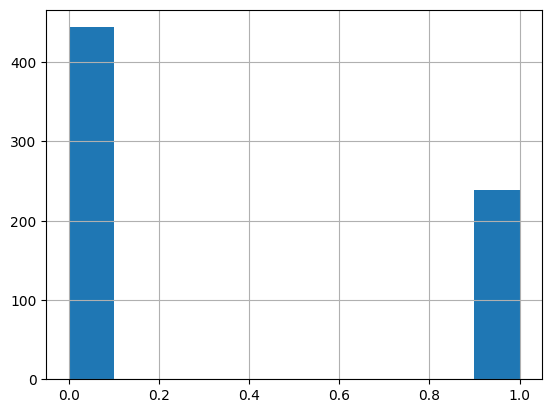

In [21]:
df_BC["Benign"].hist()

On inverse les classes 0 et 1 de la colonne Benign, car la convention de ce fichier est inversée par rapport au dataset de référence et à l’analyse des valeurs des features. Sans cette correction, une même observation serait interprétée comme “bénigne” alors que ses caractéristiques correspondent au profil “malin”, ce qui fausserait le sens du score de risque et les comparaisons SDP.

<Axes: >

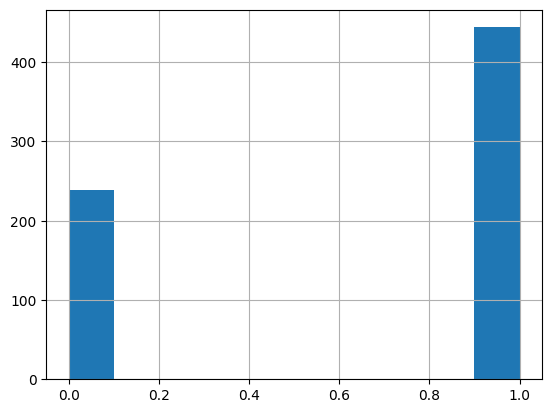

In [22]:
df_BC["Benign"] = 1 - df_BC["Benign"]
df_BC["Benign"].hist()

On récupère les coefficients appris par la régression logistique (ici on a utilisé ceux fournis) et on les transforme en poids w utilisables par les solveurs SDP, de façon à ce que “plus grand = plus à risque de cancer” corresponde bien au sens de la comparaison a ≻ b.

On définit ensuite une fonction de score de risque qui sert uniquement à orienter chaque paire : pour toute paire (i, j), on choisit a comme l’individu le plus à risque et b comme le moins à risque.

On tire un petit échantillon de 20 lignes, puis on considère toutes les comparaisons possibles entre ces individus. Pour chaque comparaison, on teste si une explication existe avec chacun des quatre solveurs (1-1, 1-m, m-1, union).

Enfin, on calcule le taux de comparaisons “expliquées” par chaque type d’explication et on produit un classement des solveurs selon leur couverture. Cela permet d’évaluer, sur des données réelles, quel formalisme d’explication est le plus souvent applicable.


In [23]:
import numpy as np
from itertools import combinations
from gurobipy import GRB

X = df_BC.drop(columns=["Benign"])
y = df_BC["Benign"]

# w et features depuis les poids fournis (pas de ré-entraînement logreg)

features = list(X.columns)

beta_vals = [0.416, 0.134, 0.247, 0.235, 0.11, 0.352, 0.304, 0.193, 0.226]
beta = dict(zip(features, beta_vals))

b0 = -8.377

# score "risque cancer" = -(beta·x + b0)  => w = -beta pour que delta aille dans le bon sens
w = {k: -beta[k] for k in features}

def cancer_risk_score(row_dict):
    return -(sum(beta[k] * row_dict[k] for k in features) + b0)

# échantillon de 100 lignes
S = df_BC.sample(n=100, random_state=42).reset_index(drop=True)
X10 = S[features]

def row_to_dict(i):
    return X10.iloc[i].to_dict()

# solveurs 
langs = {
    "1-1": lambda a, b: solve_11(a, b, w, features, silent=True),
    "1-m": lambda a, b: solve_1m(a, b, w, features, silent=True),
    "m-1": lambda a, b: solve_m1(a, b, w, features, silent=True),
    "union": lambda a, b: solve_mixed(a, b, w, features, silent=True),
}

# comptage global
tot = 0
explained = {L: 0 for L in langs}

for i, j in combinations(range(100), 2):
    xi, xj = row_to_dict(i), row_to_dict(j)

    # orienter : a ≻ b = a plus à risque de cancer
    if cancer_risk_score(xi) >= cancer_risk_score(xj):
        a, b = xi, xj
    else:
        a, b = xj, xi

    tot += 1

    for L, solver in langs.items():
        status, *others = solver(a, b)
        if status == GRB.OPTIMAL:
            explained[L] += 1

# taux global + ranking 
rates = {L: explained[L] / tot for L in langs}
print(f"Total comparaisons = {tot}")
for L in ["1-1", "1-m", "m-1", "union"]:
    print(f"{L:>5} : {explained[L]}/{tot} = {rates[L]:.3f}")

ranking = sorted(rates.keys(), key=lambda L: rates[L], reverse=True)
print("\nRanking (taux d'explication global) :", ranking)


Total comparaisons = 4950
  1-1 : 4448/4950 = 0.899
  1-m : 4678/4950 = 0.945
  m-1 : 4648/4950 = 0.939
union : 4881/4950 = 0.986

Ranking (taux d'explication global) : ['union', '1-m', 'm-1', '1-1']


#### Analyse des résultats

Sur les 100 individus échantillonnés, on obtient 4 950 comparaisons possibles. Les résultats montrent que des explications SDP existent dans la grande majorité des cas, ce qui confirme la forte applicabilité de l’approche sur le dataset Breast Cancer.

Le solveur 1-1 est le plus restrictif : il n’autorise qu’une compensation simple entre un critère favorable et un critère défavorable. Cette contrainte limite naturellement le nombre de comparaisons explicables, avec un taux de 89.9%.

Les solveurs 1-m et m-1 introduisent davantage de flexibilité en permettant des compensations groupées (un critère contre plusieurs ou plusieurs contre un). Cela améliore la couverture, avec 94.5% de comparaisons expliquées pour 1-m et 93.9% pour m-1.

Le solveur union, qui combine automatiquement les deux types de trade-offs, obtient le meilleur taux d’explication global, avec 98.6% des comparaisons justifiées. Il sélectionne pour chaque paire la structure de compensation la plus adaptée.

Ces résultats montrent que les différences entre individus sont le plus souvent explicables par des mécanismes de compensation structurés entre critères. En pratique, utiliser union en priorité permet de maximiser le nombre d’explications, tandis que 1-1 reste pertinent lorsque l’on recherche des justifications plus simples et directement interprétables.

## Dataset RATP

In [24]:
df_RATP=pd.read_csv("RATP_cleaned.csv")
df_RATP.head()

,Metro station,peak-entering-passengers/h,peak-passing-passengers/h,off-peak-entering-passengers/h,off-peak-passing-passengers/h,"strategic priority [0,10]","Station degradation level ([0,20] scale)","connectivity index [0,100]"
0,Odéon (Ligne 4),85000.0,8100.0,35500.0,3450.0,75.0,16.2,88.0
1,Place d'Italie (Lign 6),81000.0,8100.0,37500.0,3150.0,67.0,17.6,95.0
2,Jussieu (Ligne 7),74000.0,8900.0,37000.0,4050.0,68.0,16.8,79.0
3,Nation (Ligne 9),74000.0,7100.0,42000.0,4550.0,77.0,15.2,73.0
4,La Motte Picquet-Grenelle (Ligne 10),72000.0,7500.0,33000.0,4250.0,88.0,13.2,93.0


In [25]:
poids= df_RATP[df_RATP["Metro station"] == "weights"]
df_RATP_clean = df_RATP[df_RATP["Metro station"] != "weights"].copy()


In [26]:
poids

,Metro station,peak-entering-passengers/h,peak-passing-passengers/h,off-peak-entering-passengers/h,off-peak-passing-passengers/h,"strategic priority [0,10]","Station degradation level ([0,20] scale)","connectivity index [0,100]"
10,weights,0.021498,0.188111,0.037622,0.322477,16.123831,67.182629,16.123831


On calcule d’abord un score de priorité pour chaque station à partir des critères et des poids fournis. Ce score sert uniquement à établir un classement global, simple et reproductible des stations à rénover. On extrait ensuite le top k de ce classement (les k stations les plus prioritaires selon le score).

Ensuite, on ne cherche pas à recalculer l’ordre avec SDP. On utilise SDP uniquement pour vérifier si chaque comparaison du top k est explicable. Pour chaque paire de stations du top k (i < j), on teste successivement plusieurs formalismes d’explication (union en premier, puis 1-m, m-1, 1-1). Si un solveur trouve une solution, on obtient une explication SDP sous forme de trade-offs, et on considère que la comparaison “station i ≻ station j” est justifiable.

Enfin, on construit un graphe orienté des comparaisons explicables. Chaque nœud représente une station du top k avec son rang et son score. Une flèche i → j signifie que la supériorité de la station i sur la station j est justifiable par SDP (une explication a été trouvée). L’absence de flèche signifie qu’aucune explication SDP n’existe pour cette paire avec les solveurs testés, même si le score classe bien i avant j.

Le graphe sert donc à visualiser quelles parties du classement par score sont réellement justifiables sous contraintes SDP, et à mettre en évidence les zones où l’ordre est correct selon le score mais non explicable dans ce cadre formel.


In [27]:
# Graphe
import networkx as nx
import matplotlib.pyplot as plt

features = [c for c in df_RATP_clean.columns if c != "Metro station"]

w_row = poids.iloc[0]
w = {f: float(w_row[f]) for f in features}

def priority_score(row):
    return sum(w[f] * float(row[f]) for f in features)

dfX = df_RATP_clean.copy()
dfX["priority_score"] = dfX.apply(priority_score, axis=1)
df_sorted = dfX.sort_values("priority_score", ascending=False).reset_index(drop=True)


# Solveurs (union en premier) + statut lisible
SOLVERS = [
    ("union", solve_mixed),
    ("1-m",  solve_1m),
    ("m-1",  solve_m1),
    ("1-1",  solve_11),
]

def status_name(st):
    if st == GRB.OPTIMAL:    return "OPTIMAL"
    if st == GRB.INFEASIBLE: return "INFEASIBLE"
    if st == GRB.TIME_LIMIT: return "TIME_LIMIT"
    if st == GRB.UNBOUNDED:  return "UNBOUNDED"
    return str(st)

def explain_pair(a_row, b_row):
    a = a_row[features].to_dict()
    b = b_row[features].to_dict()

    statuses = {}
    for name, fn in SOLVERS:
        res = fn(a, b, w, features, silent=True)
        status, E, *_ = res
        statuses[name] = status

        if status == GRB.OPTIMAL:
            return {"type": name, "E": E}

    return {"type": None, "E": None, "statuses": statuses}


# Construire et afficher le graphe SDP explicable (top-k)
def plot_explanation_graph(topk, edges, title):
    """
    topk : df top-k trié par score
    edges : liste de tuples (i, j, label) avec i<j (indices 0-based dans topk)
    """
    G = nx.DiGraph()

    # noeuds : 1..k avec label station + score
    for i in range(len(topk)):
        node = i + 1
        station = topk.loc[i, "Metro station"]
        score = float(topk.loc[i, "priority_score"])
        G.add_node(node, station=station, score=score)

    # arêtes (comparaisons explicables)
    for i, j, lbl in edges:
        G.add_edge(i + 1, j + 1, label=lbl)

    # labels noeuds
    node_labels = {}
    for node in G.nodes():
        station = G.nodes[node]["station"]
        score = G.nodes[node]["score"]
        node_labels[node] = f"#{node} {station}\n{score:.1f}"

    # labels arêtes
    edge_labels = {(u, v): G.edges[u, v].get("label", "") for u, v in G.edges()}

    plt.figure()
    pos = nx.spring_layout(G, seed=42)
    nx.draw_networkx_nodes(G, pos)
    nx.draw_networkx_edges(G, pos, arrows=True)
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    plt.title(title)
    plt.axis("off")
    plt.show()


# Justifier top-k : toutes les paires i<j + graphe

def justify_top_k_all_pairs(k):
    topk = df_sorted.head(k).reset_index(drop=True)

    print(f"\nTOP {k} stations à rénover en priorité (par score) :")
    display(topk[["Metro station", "priority_score"]])

    edges = []  # pour le graphe : (i, j, type)

    print(f"\nJustifications TOP {k} (toutes les comparaisons i < j) :")
    for i in range(k):
        for j in range(i + 1, k):
            A = topk.iloc[i]
            B = topk.iloc[j]

            print(
                f"\n#{i+1} {A['Metro station']} ≻ #{j+1} {B['Metro station']} "
                f"(score {A['priority_score']:.4f} vs {B['priority_score']:.4f})"
            )

            out = explain_pair(A, B)

            if out["type"] is not None:
                print(f"Type: {out['type']}")
                print(f"E: {out['E']}")
                edges.append((i, j, out["type"]))
            else:
                print("Aucune explication SDP trouvée. Statuts par solveur :")
                for name, st in out["statuses"].items():
                    print(f"  {name:>5} : {status_name(st)}")

    
    plot_explanation_graph(
        topk=topk,
        edges=edges,
        title=f"RATP - Graphe des comparaisons explicables (top {k})"
    )




TOP 3 stations à rénover en priorité (par score) :


,Metro station,priority_score
0,Odéon (Ligne 4),9515.747608
1,Place d'Italie (Lign 6),9486.187251
2,Jussieu (Ligne 7),9462.001505



Justifications TOP 3 (toutes les comparaisons i < j) :

#1 Odéon (Ligne 4) ≻ #2 Place d'Italie (Lign 6) (score 9515.7476 vs 9486.1873)
Type: union
E: [('1m', 'strategic priority [0,10]', ('connectivity index [0,100]',)), ('m1', ('peak-entering-passengers/h',), 'off-peak-entering-passengers/h'), ('m1', ('off-peak-passing-passengers/h',), 'Station degradation level ([0,20]  scale)')]

#1 Odéon (Ligne 4) ≻ #3 Jussieu (Ligne 7) (score 9515.7476 vs 9462.0015)
Aucune explication SDP trouvée. Statuts par solveur :
  union : INFEASIBLE
    1-m : INFEASIBLE
    m-1 : INFEASIBLE
    1-1 : INFEASIBLE

#2 Place d'Italie (Lign 6) ≻ #3 Jussieu (Ligne 7) (score 9486.1873 vs 9462.0015)
Aucune explication SDP trouvée. Statuts par solveur :
  union : INFEASIBLE
    1-m : INFEASIBLE
    m-1 : INFEASIBLE
    1-1 : INFEASIBLE


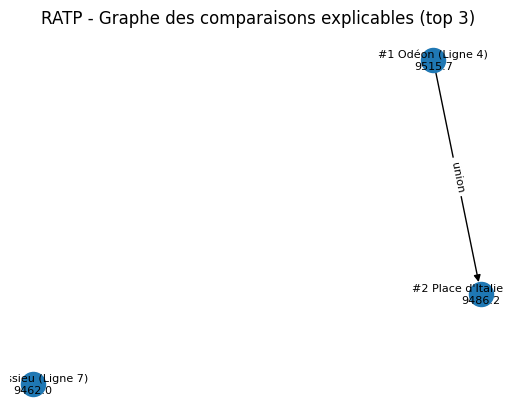

In [28]:
justify_top_k_all_pairs(3)

La comparaison Odéon ≻ Place d’Italie est explicable avec le solveur union. L’explication obtenue repose sur une combinaison de trade-offs de type 1-m et m-1, ce qui signifie que certains critères favorables d’Odéon compensent des critères défavorables de Place d’Italie de manière structurée.

En revanche, les comparaisons Odéon ≻ Jussieu et Place d’Italie ≻ Jussieu ne sont explicables par aucun des solveurs testés (union, 1-m, m-1, 1-1), tous infaisables. Cela ne remet pas en cause le classement par score, mais indique que la supériorité sur Jussieu provient d’écarts plus diffus, qui ne peuvent pas être décomposés sous la forme de trade-offs disjoints imposée par les explications SDP.

Le graphe associé synthétise ces résultats : une arête orientée relie Odéon à Place d’Italie, montrant que cette comparaison est justifiable par SDP, tandis qu’aucune arête n’apparaît vers Jussieu, ce qui visualise directement l’absence d’explication formelle pour ces relations malgré leur ordre dans le classement par score.


TOP 5 stations à rénover en priorité (par score) :


,Metro station,priority_score
0,Odéon (Ligne 4),9515.747608
1,Place d'Italie (Lign 6),9486.187251
2,Jussieu (Ligne 7),9462.001505
3,Nation (Ligne 9),9413.630012
4,La Motte Picquet-Grenelle (Ligne 10),9376.007739



Justifications TOP 5 (toutes les comparaisons i < j) :

#1 Odéon (Ligne 4) ≻ #2 Place d'Italie (Lign 6) (score 9515.7476 vs 9486.1873)
Type: union
E: [('1m', 'strategic priority [0,10]', ('connectivity index [0,100]',)), ('m1', ('peak-entering-passengers/h',), 'off-peak-entering-passengers/h'), ('m1', ('off-peak-passing-passengers/h',), 'Station degradation level ([0,20]  scale)')]

#1 Odéon (Ligne 4) ≻ #3 Jussieu (Ligne 7) (score 9515.7476 vs 9462.0015)
Aucune explication SDP trouvée. Statuts par solveur :
  union : INFEASIBLE
    1-m : INFEASIBLE
    m-1 : INFEASIBLE
    1-1 : INFEASIBLE

#1 Odéon (Ligne 4) ≻ #4 Nation (Ligne 9) (score 9515.7476 vs 9413.6300)
Aucune explication SDP trouvée. Statuts par solveur :
  union : INFEASIBLE
    1-m : INFEASIBLE
    m-1 : INFEASIBLE
    1-1 : INFEASIBLE

#1 Odéon (Ligne 4) ≻ #5 La Motte Picquet-Grenelle (Ligne 10) (score 9515.7476 vs 9376.0077)
Type: union
E: [('1m', 'peak-passing-passengers/h', ('connectivity index [0,100]',)), ('m1', ('pea

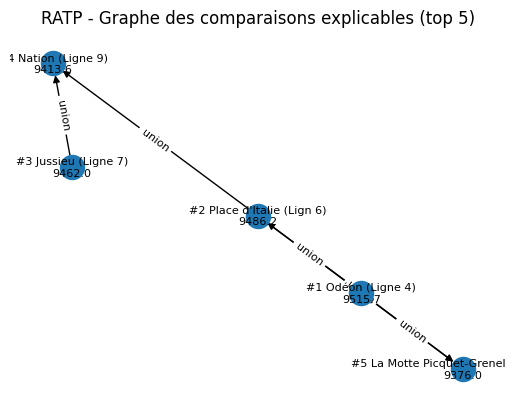

In [29]:
justify_top_k_all_pairs(5)

Voici le markdown enrichi avec le lien explicite au graphe top 5 :

Plusieurs comparaisons sont explicables avec le solveur union, ce qui signifie que la supériorité peut être décrite par une combinaison de compensations structurées entre critères (trade-offs 1-m et m-1). Dans ce top 5, des explications existent notamment pour :

Odéon ≻ Place d’Italie

Odéon ≻ La Motte Picquet-Grenelle

Place d’Italie ≻ Nation

Place d’Italie ≻ La Motte Picquet-Grenelle

Jussieu ≻ Nation

En revanche, certaines paires restent inexplicables : tous les solveurs testés (union, 1-m, m-1, 1-1) renvoient INFEASIBLE. Cela signifie que, même si l’ordre est correct au sens du score, l’écart entre ces deux stations ne peut pas être décomposé sous la forme de trade-offs disjoints imposée par le formalisme SDP. Concrètement, la supériorité provient alors d’un ensemble d’écarts plus diffus, qui ne se laissent pas isoler en compensations simples.

Le graphe de comparaisons explicables permet de visualiser directement ces résultats : les flèches orientées relient les stations pour lesquelles une justification SDP existe, formant une structure partielle du classement (chaîne Odéon → Place d’Italie → Jussieu → Nation, ainsi qu’une branche vers La Motte Picquet-Grenelle). L’absence de flèche entre certaines paires correspond exactement aux comparaisons inexplicables observées dans les résultats numériques.


Conclusion :  

Le score fournit un ordre global cohérent pour prioriser les rénovations, et les explications SDP permettent de justifier localement une partie des comparaisons. Le graphe synthétise ces justifications de manière intuitive, tandis que l’absence d’arêtes sur certaines paires met en évidence une limite d’expressivité du formalisme SDP plutôt qu’une incohérence du classement.

## Dataset 27crit

In [30]:
crit=pd.read_csv("data27crit.csv", sep=";")
crit.head()

,sol,a,b,c,d,e,f,g,h,i,...,r,s,t,u,v,w,x,y,z,A
0,solution 1,532,120,330,54,12,125,320,"59,4",125,...,125,577,231,677,32,197,123,224,"324,1",53
1,solution 2,94,-756,"174,4","-254,6666667","225,5","162,3333333",670,"19,97142857","127,5",...,"239,3333333",155,349,363,206,294,201,"214,8","142,9",465
2,solution 3,174,652,-1094,-176,-854,-573,6,"50,6",515,...,-479,107,-37,-483,706,-301,27,490,"-922,1",-717
3,solution 4,604,976,680,-52,-234,333,-254,"-608,6",-523,...,927,-295,769,-39,-192,-509,199,54,"-393,9",617
4,weights,2,1,5,3,4,6,1,7,4,...,6,2,7,1,2,6,3,5,5,1


In [31]:
poids= crit[crit["sol"] == "weights"]
crit = crit[crit["sol"] != "weights"].copy()

In [32]:
crit.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, 0 to 3
Data columns (total 28 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   sol     4 non-null      object
 1   a       4 non-null      int64 
 2   b       4 non-null      int64 
 3   c       4 non-null      object
 4   d       4 non-null      object
 5   e       4 non-null      object
 6   f       4 non-null      object
 7   g       4 non-null      int64 
 8   h       4 non-null      object
 9   i       4 non-null      object
 10  j       4 non-null      object
 11  k       4 non-null      int64 
 12  l       4 non-null      object
 13  m       4 non-null      int64 
 14  n       4 non-null      int64 
 15  o       4 non-null      int64 
 16  p       4 non-null      int64 
 17  q       4 non-null      object
 18  r       4 non-null      object
 19  s       4 non-null      int64 
 20  t       4 non-null      int64 
 21  u       4 non-null      int64 
 22  v       4 non-null      int64 
 23 

In [33]:
crit_clean = crit.copy()
num_cols = [c for c in crit.columns if c != "sol"]

# remplacer "," par "." uniquement sur les colonnes non numériques
for c in num_cols:
    if crit_clean[c].dtype == "object":
        crit_clean[c] = crit_clean[c].astype(str).str.replace(",", ".", regex=False)

    crit_clean[c] = pd.to_numeric(crit_clean[c], errors="coerce")



In [34]:
crit_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, 0 to 3
Data columns (total 28 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sol     4 non-null      object 
 1   a       4 non-null      int64  
 2   b       4 non-null      int64  
 3   c       4 non-null      float64
 4   d       4 non-null      float64
 5   e       4 non-null      float64
 6   f       4 non-null      float64
 7   g       4 non-null      int64  
 8   h       4 non-null      float64
 9   i       4 non-null      float64
 10  j       4 non-null      float64
 11  k       4 non-null      int64  
 12  l       4 non-null      float64
 13  m       4 non-null      int64  
 14  n       4 non-null      int64  
 15  o       4 non-null      int64  
 16  p       4 non-null      int64  
 17  q       4 non-null      float64
 18  r       4 non-null      float64
 19  s       4 non-null      int64  
 20  t       4 non-null      int64  
 21  u       4 non-null      int64  
 22  v       4 n

In [35]:
crit_clean.head()

,sol,a,b,c,d,e,f,g,h,i,...,r,s,t,u,v,w,x,y,z,A
0,solution 1,532,120,330.0,54.000000,12.0,125.000000,320,59.400000,125.0,...,125.000000,577,231,677,32,197,123,224.0,324.1,53
1,solution 2,94,-756,174.4,-254.666667,225.5,162.333333,670,19.971429,127.5,...,239.333333,155,349,363,206,294,201,214.8,142.9,465
2,solution 3,174,652,-1094.0,-176.000000,-854.0,-573.000000,6,50.600000,515.0,...,-479.000000,107,-37,-483,706,-301,27,490.0,-922.1,-717
3,solution 4,604,976,680.0,-52.000000,-234.0,333.000000,-254,-608.600000,-523.0,...,927.000000,-295,769,-39,-192,-509,199,54.0,-393.9,617


On applique exactement la même procédure que pour le dataset RATP, mais cette fois sur le dataset crit avec 27 critères. On commence par construire un score global de priorité pour chaque solution sol en utilisant la somme pondérée des critères avec les poids fournis. Ce score permet d’obtenir un classement complet et reproductible de toutes les solutions.

Ensuite, on cherche à justifier cet ordre avec les explications SDP. Pour rester simple et éviter un nombre de comparaisons trop élevé, on ne compare que des solutions consécutives dans le classement (solution #1 contre #2, #2 contre #3, etc.). Pour chaque comparaison, on teste successivement les solveurs SDP (union, 1-m, m-1, 1-1) et on retourne la première explication trouvée. Si aucune explication n’existe, on affiche le statut exact de chaque solveur pour diagnostiquer si c’est une vraie impossibilité structurelle.

L’intérêt ici est de vérifier si les mécanismes d’explication SDP restent applicables lorsque le nombre de critères augmente fortement (27 au lieu de 7). Avec plus de critères, les différences entre solutions sont souvent plus “diffuses” et peuvent rendre certaines comparaisons infaisables sous les contraintes SDP strictes.



Classement complet (par score) :


,sol,priority_score
0,solution 1,19725.300000
1,solution 2,17653.299999
2,solution 4,15711.300000
3,solution 3,-15731.300000



Justifications complètes (toutes les paires i < j) :

#1 solution 1 ≻ #2 solution 2 (score 19725.3000 vs 17653.3000)
Type: union
E: [('1m', 'a', ('f', 'x', 'A')), ('1m', 'b', ('q', 'v')), ('1m', 'm', ('k',)), ('1m', 'n', ('g', 'w')), ('1m', 'z', ('i', 'l', 't')), ('m1', ('j',), 'e'), ('m1', ('s', 'u'), 'p'), ('m1', ('h', 'o', 'y'), 'r')]

#1 solution 1 ≻ #3 solution 4 (score 19725.3000 vs 15711.3000)
Type: union
E: [('1m', 'h', ('q', 't', 'x')), ('1m', 'k', ('a', 'f', 'o', 'p', 'A')), ('1m', 'w', ('b', 'c', 'n')), ('m1', ('i', 'z'), 'l'), ('m1', ('d', 'g', 'm', 's', 'u', 'v', 'y'), 'r')]

#1 solution 1 ≻ #4 solution 3 (score 19725.3000 vs -15731.3000)
Type: union
E: [('1m', 'c', ('b', 'i', 'l', 'p', 'v', 'y')), ('m1', ('f', 'o'), 'k')]

#2 solution 2 ≻ #3 solution 4 (score 17653.3000 vs 15711.3000)
Type: union
E: [('1m', 'e', ('a', 'd', 'A')), ('1m', 'h', ('b', 'f', 'p')), ('1m', 'k', ('c', 'n', 'q')), ('1m', 'w', ('j', 'm', 'o', 't')), ('m1', ('g', 'i', 'x', 'y'), 'l'), ('m1', ('s', 

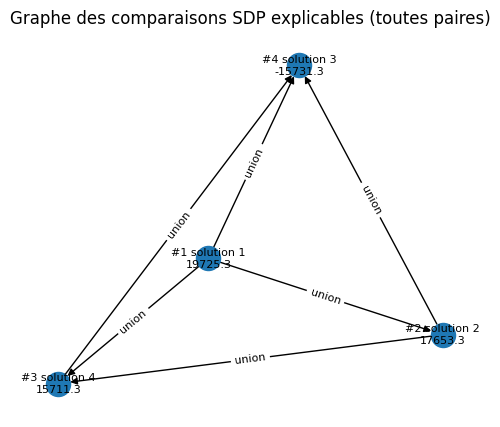

In [36]:
import networkx as nx
import matplotlib.pyplot as plt
from gurobipy import GRB


# score + tri global

NAME_COL = "sol"
features = [c for c in crit_clean.columns if c != NAME_COL]

# poids
w_row = poids.iloc[0]
w = {f: float(pd.to_numeric(w_row[f], errors="coerce")) for f in features}

# score global
def priority_score(row):
    return sum(w[f] * float(row[f]) for f in features)

dfX = crit_clean.copy()
dfX["priority_score"] = dfX.apply(priority_score, axis=1)

df_sorted = dfX.sort_values("priority_score", ascending=False).reset_index(drop=True)

print("\nClassement complet (par score) :")
display(df_sorted[[NAME_COL, "priority_score"]])


# Solveurs SDP

SOLVERS = [
    ("union", solve_mixed),
    ("1-m",  solve_1m),
    ("m-1",  solve_m1),
    ("1-1",  solve_11),
]

def status_name(st):
    if st == GRB.OPTIMAL:    return "OPTIMAL"
    if st == GRB.INFEASIBLE: return "INFEASIBLE"
    if st == GRB.UNBOUNDED:  return "UNBOUNDED"
    if st == GRB.TIME_LIMIT:return "TIME_LIMIT"
    return str(st)

def explain_pair(a_row, b_row):

    a = a_row[features].to_dict()
    b = b_row[features].to_dict()

    statuses = {}

    for name, fn in SOLVERS:

        status, E, *_ = fn(a, b, w, features, silent=True)
        statuses[name] = status

        if status == GRB.OPTIMAL:
            return {"type": name, "E": E}

    return {"type": None, "E": None, "statuses": statuses}


#  Graphe SDP

def plot_graph(df_sorted, edges):

    G = nx.DiGraph()

    n = len(df_sorted)

    # noeuds
    for i in range(n):
        label = df_sorted.loc[i, NAME_COL]
        score = df_sorted.loc[i, "priority_score"]
        G.add_node(i+1, label=label, score=score)

    # arêtes
    for i, j, t in edges:
        G.add_edge(i+1, j+1, label=t)

    node_labels = {
        i+1: f"#{i+1} {df_sorted.loc[i, NAME_COL]}\n{df_sorted.loc[i, 'priority_score']:.1f}"
        for i in range(n)
    }

    edge_labels = {(u, v): G.edges[u, v]["label"] for u, v in G.edges()}

    plt.figure(figsize=(6,5))
    pos = nx.spring_layout(G, seed=42)

    nx.draw_networkx_nodes(G, pos)
    nx.draw_networkx_edges(G, pos, arrows=True)
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Graphe des comparaisons SDP explicables (toutes paires)")
    plt.axis("off")
    plt.show()


#  Toutes les paires + graphe


print("\nJustifications complètes (toutes les paires i < j) :")

edges = []   # pour le graphe

n = len(df_sorted)

for i in range(n):
    for j in range(i+1, n):

        A = df_sorted.iloc[i]
        B = df_sorted.iloc[j]

        print(
            f"\n#{i+1} {A[NAME_COL]} ≻ #{j+1} {B[NAME_COL]} "
            f"(score {A['priority_score']:.4f} vs {B['priority_score']:.4f})"
        )

        out = explain_pair(A, B)

        if out["type"] is not None:

            print(f"Type: {out['type']}")
            print(f"E: {out['E']}")

            edges.append((i, j, out["type"]))

        else:
            print("Aucune explication SDP trouvée.")
            for name, st in out["statuses"].items():
                print(f"  {name:>5} : {status_name(st)}")


# Affichage du graphe

plot_graph(df_sorted, edges)


Le classement par score donne l’ordre suivant : solution 1 > solution 2 > solution 4 > solution 3. On observe une séparation très nette avec solution 3, dont le score est fortement négatif, ce qui indique qu’elle est globalement dominée sur une grande partie des critères.

Ici, toutes les comparaisons par paires entre les 4 solutions sont explicables avec le solveur union. Autrement dit, pour chaque paire (i, j) avec i mieux classée que j, on arrive à construire une justification SDP sous forme de trade-offs entre critères favorables et défavorables. C’est un résultat important : malgré 27 critères, le formalisme arrive à produire une décomposition cohérente des supériorités, sans “trous” d’inexplicabilité.

Les explications obtenues sont systématiquement de type union, donc composées d’un mélange de trade-offs 1-m et m-1. Cela montre que la hiérarchie ne tient pas à un seul critère dominant, mais à des compensations structurées réparties sur plusieurs critères (plusieurs petits avantages qui compensent plusieurs désavantages, et parfois l’inverse).

Le graphe résume visuellement ces comparaisons explicables : une arête orientée i -> j signifie que la supériorité de i sur j est justifiable par SDP, et l’étiquette union indique quel solveur a fourni l’explication. Comme toutes les arêtes attendues existent ici, le graphe confirme que le classement est entièrement “couvert” par des justifications SDP sur l’ensemble des paires.

Conclusion : 

Le score permet d’établir un ordre global clair entre les solutions et, pour ce dataset à 27 critères, les explications SDP obtenues avec le solveur union parviennent à justifier l’ensemble des comparaisons, y compris sur toutes les paires. Contrairement au cas des stations RATP, aucune comparaison ne reste ici inexplicable. Cela montre que, dans ce problème précis, les écarts entre solutions se prêtent bien à une décomposition en trade-offs structurés. La présence d’un grand nombre de critères offre davantage de possibilités de compensations entre dimensions favorables et défavorables, ce qui facilite la construction d’explications SDP, sans pour autant constituer une propriété générale valable pour tous les jeux de données.